In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_excel(r'C:\Users\USER\OneDrive\hr_data 1.xlsx')
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Employee_ID          1000 non-null   int64         
 1   Name                 1000 non-null   str           
 2   Age                  1000 non-null   int64         
 3   Gender               1000 non-null   str           
 4   Department           1000 non-null   str           
 5   Position             1000 non-null   str           
 6   Salary               1000 non-null   int64         
 7   Bonus                1000 non-null   int64         
 8   Experience_Years     1000 non-null   int64         
 9   Attendance_Pct       1000 non-null   float64       
 10  Leave_Days           1000 non-null   int64         
 11  Performance_Rating   1000 non-null   int64         
 12  Target_Achieved      1000 non-null   str           
 13  Work_Mode            1000 non-null   str     

In [6]:
df.drop_duplicates()

,Employee_ID,Name,Age,Gender,Department,Position,Salary,Bonus,Experience_Years,Attendance_Pct,...,Performance_Rating,Target_Achieved,Work_Mode,City,Marital_Status,Training_Hours,Job_Satisfaction,Overtime_Hours,Promotion_Last_3Yrs,Join_Date
0,1001,Employee_1,58,Female,IT,Manager,259402,33916,3,72.59,...,4,Yes,Remote,Lahore,Single,23,9,32,No,2021-06-19
1,1002,Employee_2,48,Female,Marketing,Team Lead,146956,9927,7,86.96,...,4,Yes,Office,Faisalabad,Single,97,4,6,No,2020-12-10
2,1003,Employee_3,34,Male,Operations,Junior,158452,32964,4,93.77,...,2,Yes,Office,Islamabad,Married,71,9,8,No,2020-01-14
3,1004,Employee_4,27,Female,Marketing,Junior,226823,16164,15,96.63,...,5,Yes,Hybrid,Islamabad,Single,32,3,0,No,2024-08-28
4,1005,Employee_5,40,Male,Operations,Senior,166311,42158,3,88.72,...,3,Yes,Hybrid,Lahore,Single,22,1,15,No,2019-01-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1996,Employee_996,27,Female,Finance,Intern,183279,21524,1,63.07,...,3,Yes,Hybrid,Peshawar,Married,30,1,29,No,2025-05-03
996,1997,Employee_997,47,Male,HR,Junior,236846,33202,0,76.55,...,2,Yes,Remote,Karachi,Single,91,4,53,No,2018-02-02
997,1998,Employee_998,50,Female,IT,Senior,204044,5016,15,87.16,...,4,Yes,Remote,Islamabad,Single,61,4,45,No,2021-07-23
998,1999,Employee_999,28,Female,Sales,Team Lead,181871,21848,17,69.47,...,4,Yes,Office,Karachi,Married,27,5,34,No,2025-06-05


<Axes: xlabel='Performance_Rating', ylabel='Attendance_Pct'>

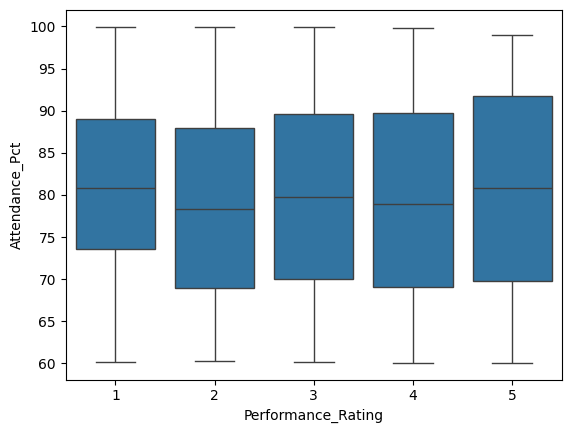

In [7]:
sns.boxplot(data=df,x='Performance_Rating',y='Attendance_Pct')
#no outliesr

In [8]:
def unique_check(col):
    print(f'unique valuse in {col } are:')
    for x in df[col].unique():
        print(x)
unique_check('Gender')
unique_check('Department')
unique_check('Work_Mode')
unique_check('Marital_Status')


unique valuse in Gender are:
Female
Male
unique valuse in Department are:
IT
Marketing
Operations
Finance
HR
Sales
unique valuse in Work_Mode are:
Remote
Office
Hybrid
unique valuse in Marital_Status are:
Single
Married


In [13]:
df.groupby('Department')[['Salary','Bonus']].mean()

,Salary,Bonus
Department,,
Finance,176637.735714,28274.828571
HR,167037.890323,26607.619355
IT,178180.479769,27465.919075
Marketing,168482.786096,27304.502674
Operations,168610.642857,28447.976190
Sales,159904.259887,27675.836158


<Axes: >

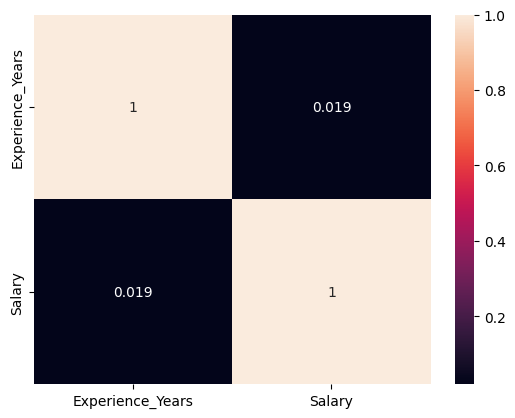

In [20]:
correlation = df[['Experience_Years','Salary']].corr()
sns.heatmap(correlation,annot=True)

In [25]:
df.groupby('Promotion_Last_3Yrs')['Performance_Rating'].mean()/(df['Performance_Rating'].max())*100

Promotion_Last_3Yrs
No     61.643489
Yes    60.669856
Name: Performance_Rating, dtype: float64

C:\Users\USER\AppData\Local\Temp\ipykernel_16040\4141313923.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=analyse.index,y=analyse.values,palette='rainbow')


Text(0.5, 1.0, 'gender wise salary analysing')

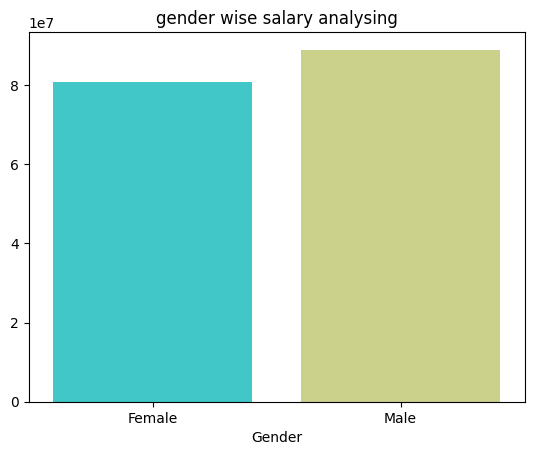

In [29]:
analyse = df.groupby('Gender')['Salary'].sum()
sns.barplot(x=analyse.index,y=analyse.values,palette='rainbow')
plt.title('gender wise salary analysing')

<Axes: >

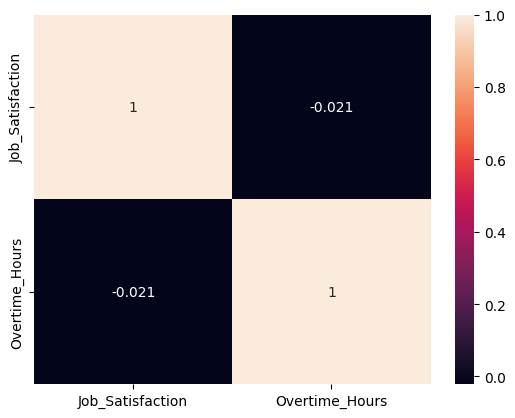

In [39]:
cor = df[['Job_Satisfaction','Overtime_Hours',]].corr()
sns.heatmap(cor,annot=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_16040\1873756452.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['City'],palette='rainbow')


<Axes: xlabel='City', ylabel='count'>

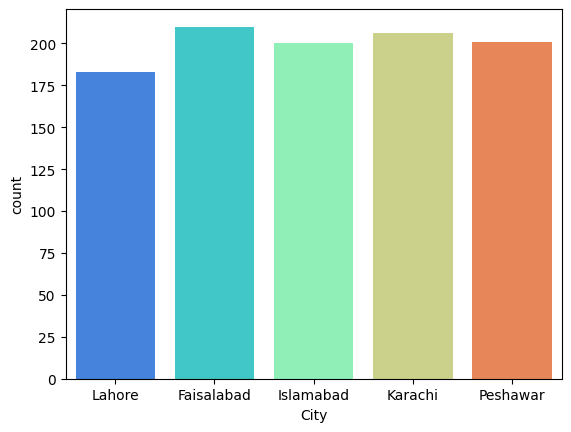

In [49]:
df['City'].value_counts()
sns.countplot(x=df['City'],palette='rainbow')

In [ ]:
from datetime import datetime as dt
join_date = pd.to_datetime(df['Join_Date'])
today = pd.to_datetime(dt.now().date())
gop = today - join_date
gop/



ValueError: Unit Y is not supported. Only unambiguous timedelta values durations are supported. Allowed units are 'W', 'D', 'h', 'm', 's', 'ms', 'us', 'ns'